# AI-Based Earthquake Catalog - Salton Sea Geothermal Region

---

**Project:** Building AI-Based High-Resolution Earthquake Catalog, Salton Sea Geothermal Region  
**Model:** [SAR (Self-Attention RNN)](https://doi.org/10.1029/2025JB031294)  
**Model Checkpoint:** `osdf:///ndp/public/ucr_seis/models/8700_17-319.ckpt`  
**Docker Image:** [bpari004/seisai:v1.0](https://hub.docker.com/r/bpari004/seisai)  
**Data:** Pelican OSDF — `osdf:///ndp/public/ucr_seis/Data_Salton`

### What this notebook does

This notebook runs a complete automated earthquake detection pipeline on **8 days of continuous seismic data** from the Salton Sea region (August 23–30, 2012), covering the **2012 Brawley Seismic Swarm** — one of the most significant seismic sequences in Southern California that year.

The pipeline has **3 main steps:**

| Step | What it does | Output |
|------|-------------|--------|
| **1. Setup** | Download data & model from Pelican OSDF | MiniSEED files + checkpoint |
| **2. Phase Picking** | SAR model detects P & S arrivals at each station | `.pick` files |
| **3. Association** | clusters picks into earthquake events | `catalog.csv` |

### Why Deep Learning?

Traditional STA/LTA detectors struggle with:
- **Low SNR** microseismic events
- **Geothermal noise** (pump noise < 2 Hz)
- **Dense seismic swarms** where events overlap

The **SAR model** uses a Bidirectional GRU + Multihead Self-Attention architecture trained on 56,554 labeled waveforms from Southern California (CEED dataset, 2008–2012). It achieves:
- **P-wave F1:** 95.89%
- **S-wave F1:** 95.14%
- **Both P+S detected:** 95.98% of events

---


---
## 📦 Cell 1 — Install Dependencies

We install any missing packages. Most are pre-installed in the `SeisAI` Docker image (`bpari004/seisai:v1.0`).

> ⏱ **Expected time:** ~30 seconds (skipped if already installed)

In [1]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# Core packages
required = ['obspy', 'torch', 'numpy', 'scipy', 'matplotlib', 
            'pandas', 'cartopy', 'tqdm', 'fsspec', 'pelicanfs']

for pkg in required:
    try:
        __import__(pkg)
        print(f'  ✅ {pkg}')
    except ImportError:
        print(f'  📦 Installing {pkg}...')
        install(pkg)
        print(f'  ✅ {pkg} installed')

print('\nAll dependencies ready!')

  ✅ obspy
  ✅ torch
  ✅ numpy
  ✅ scipy
  ✅ matplotlib
  ✅ pandas
  ✅ cartopy
  ✅ tqdm
  ✅ fsspec
  ✅ pelicanfs

All dependencies ready!


---
## 📚 Cell 2 — Import Libraries

Import all Python libraries needed for the pipeline.

In [2]:
import os
import sys
import glob
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

import torch
from obspy import UTCDateTime, read

# Check GPU availability
print('=' * 50)
print('Environment Check')
print('=' * 50)
print(f'Python     : {sys.version.split()[0]}')
print(f'PyTorch    : {torch.__version__}')

import obspy
print(f'ObsPy      : {obspy.__version__}')

if torch.cuda.is_available():
    print(f'GPU        : ✅ CUDA — {torch.cuda.get_device_name(0)}')
    GPU_IDX = 0
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    print(f'GPU        : ✅ Apple MPS')
    GPU_IDX = -1  # MPS handled inside picker
else:
    print(f'GPU        : ⚠️  CPU only (picking will be slower)')
    GPU_IDX = -1

print('=' * 50)

Environment Check
Python     : 3.11.10
PyTorch    : 2.7.1+cu118
ObsPy      : 1.5.0
GPU        : ✅ CUDA — NVIDIA GeForce RTX 2080 Ti


---
## ⚙️ Cell 3 — Configuration

All paths, dates, and parameters are set here in one place.

> 🔧 **This is the only cell you need to edit** if you want to change the time range or output location.

### About the dataset
- **Aug 23–25:** Quiet background seismicity (baseline)
- **Aug 26–30:** 2012 Brawley Seismic Swarm (peak Aug 27)
- **29 stations:** CI (broadband HH), XD (broadband BH), ZY (short period EH)
- **Region:** Southern Salton Sea — junction of San Andreas & Imperial faults

In [4]:
# ── Pelican OSDF paths ────────────────────────────────────────────────────────
PELICAN_DATA  = 'osdf:///ndp/public/ucr_seis/Data_Salton'
PELICAN_MODEL = 'osdf:///ndp/public/ucr_seis/models/8700_17-319.ckpt'

# ── Local working directory ───────────────────────────────────────────────────
# Only picks and output are written locally — no data download needed
WORK_DIR   = '/home/jovyan/work/_User-Persistent-Storage_CephBlock_/salton_sea_demo'
PICK_DIR   = os.path.join(WORK_DIR, 'picks')
OUTPUT_DIR = os.path.join(WORK_DIR, 'output')
SCRIPT_DIR = os.path.dirname(os.path.abspath('__file__'))

# ── Station file ──────────────────────────────────────────────────────────────
STA_FILE = os.path.join(SCRIPT_DIR, 'config', 'salton_sea.sta')

# ── Time range ────────────────────────────────────────────────────────────────
# 3 quiet days (Aug 23-25) + 5 swarm days (Aug 26-30)
TIME_RANGE = '20120823-20120831'
START_DATE = '20120823'
END_DATE   = '20120830'

# Create output directories
for d in [WORK_DIR, PICK_DIR, OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)

# Add script directory to path
sys.path.insert(0, SCRIPT_DIR)

print('Configuration:')
print(f'  Pelican data  : {PELICAN_DATA}')
print(f'  Pelican model : {PELICAN_MODEL}')
print(f'  Picks dir     : {PICK_DIR}')
print(f'  Output dir    : {OUTPUT_DIR}')
print(f'  Station file  : {STA_FILE}')
print(f'  Time range    : {START_DATE} → {END_DATE}')
print(f'  GPU index     : {GPU_IDX}')
print('\n✅ Configuration complete — data streams directly from Pelican')

Configuration:
  Pelican data  : osdf:///ndp/public/ucr_seis/Data_Salton
  Pelican model : osdf:///ndp/public/ucr_seis/models/8700_17-319.ckpt
  Picks dir     : /home/jovyan/work/_User-Persistent-Storage_CephBlock_/salton_sea_demo/picks
  Output dir    : /home/jovyan/work/_User-Persistent-Storage_CephBlock_/salton_sea_demo/output
  Station file  : /home/jovyan/work/_User-Persistent-Storage_CephBlock_/salton_sea_demo/config/salton_sea.sta
  Time range    : 20120823 → 20120830
  GPU index     : 0

✅ Configuration complete — data streams directly from Pelican


---
## 🛰️ Cell 4 — Data from Pelican OSDF

We pull the seismic data and trained model checkpoint from **Pelican OSDF** — the Open Science Data Federation, a public data highway for science.

### What is Pelican OSDF?
- A distributed data network that caches scientific datasets close to where compute runs
- Hosted at `osdf:///ndp/public/ucr_seis/` — publicly accessible to anyone
- Data transfers directly into NDP storage — no manual download needed

### What we're downloading
- **6.4 GB** of continuous MiniSEED waveforms — 8 days × 29 stations × 3 components
- **~50 MB** model checkpoint — `8700_17-319.ckpt` (trained SAR model)

> ⏱ **Expected time:** 5–15 minutes depending on network speed

In [10]:
import fsspec
from pelicanfs.core import OSDFFileSystem

print('Verifying data and model on Pelican OSDF...')
print('=' * 55)

fs = OSDFFileSystem()

# Verify data folders
data_path = '/ndp/public/ucr_seis/Data_Salton'
day_folders = []
for obj in fs.ls(data_path):
    name = obj['name'].rstrip('/').split('/')[-1]  # strip trailing slash
    if name.startswith('2012'):
        day_folders.append(name)

day_folders = sorted(day_folders)
print(f'Data folders on Pelican: {len(day_folders)} days')
for day in day_folders:
    if day == '20120827':
        label = ' <- swarm peak'
    elif '20120826' <= day <= '20120830':
        label = ' <- swarm'
    else:
        label = ' <- quiet'
    print(f'  {day}{label}')

# Verify model checkpoint
model_path = 'osdf:///ndp/public/ucr_seis/models/8700_17-319.ckpt'
with fsspec.open(model_path) as f:
    state = torch.load(f, map_location=torch.device('cpu'))
    n_keys = len(state.keys())

print('')
print('Model checkpoint on Pelican:')
print(f'  Path   : {model_path}')
print(f'  Layers : {n_keys} weight tensors loaded')
print('  Status : Accessible directly from Pelican')
print('')
print('All data verified - no download needed!')

PELICAN_FS = fs

Verifying data and model on Pelican OSDF...
Data folders on Pelican: 8 days
  20120823 <- quiet
  20120824 <- quiet
  20120825 <- quiet
  20120826 <- swarm
  20120827 <- swarm peak
  20120828 <- swarm
  20120829 <- swarm
  20120830 <- swarm

Model checkpoint on Pelican:
  Path   : osdf:///ndp/public/ucr_seis/models/8700_17-319.ckpt
  Layers : 22 weight tensors loaded
  Status : Accessible directly from Pelican

All data verified - no download needed!


---
## 🗺️ Cell 5 — Explore the Station Network

Before picking, let's visualize our **29-station network** across the Salton Sea region.

### Station Networks
| Network | Stations | Channel | Sample Rate | Operator |
|---------|----------|---------|-------------|----------|
| **CI** | 11 | HH (broadband) | 100 Hz | SCEDC / Caltech |
| **XD** | 17 | BH (broadband) | 40 Hz | IRIS PASSCAL |
| **ZY** | 1 | EH (short period) | 100 Hz | |

The denser XD network was deployed specifically for geothermal monitoring — it gives us excellent coverage of the Brawley Seismic Zone.

Total stations: 30
net
CI    11
XD    18
ZY     1
CFM fault segments in map extent: 49


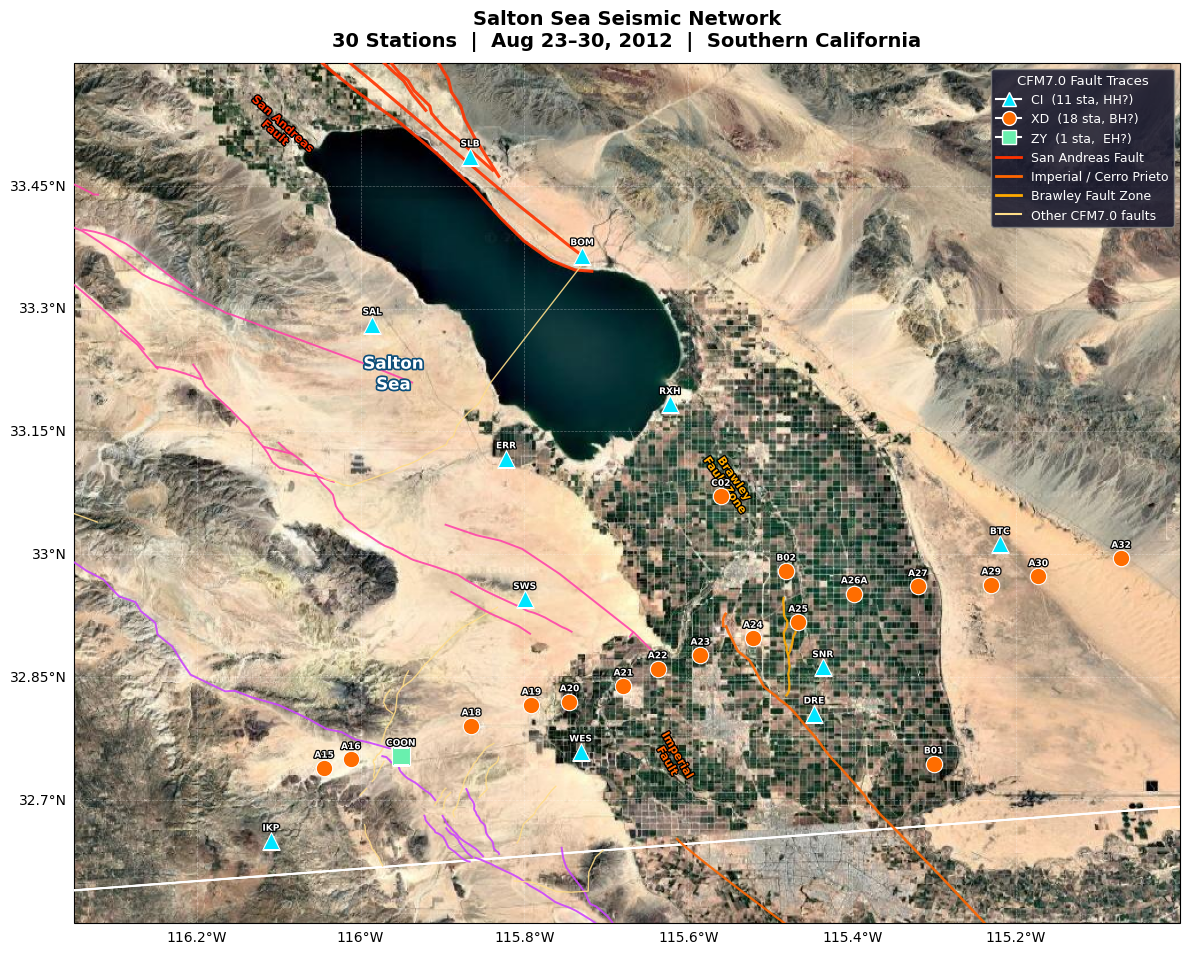

Saved: /home/jovyan/work/_User-Persistent-Storage_CephBlock_/salton_sea_demo/output/station_map.png


In [16]:
# ── Cell 5 — Station Network Map ─────────────────────────────────────────────
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patheffects as pe
import pandas as pd
import numpy as np

# ── Read station file ─────────────────────────────────────────────────────────
stations = []
with open(STA_FILE) as f:
    for line in f:
        codes = line.strip().split(',')
        if len(codes) >= 4:
            net_sta = codes[0]
            net, sta = net_sta.split('.')
            lat, lon = float(codes[1]), float(codes[2])
            stations.append({'net': net, 'sta': sta, 'net_sta': net_sta,
                             'lat': lat, 'lon': lon})
df_sta = pd.DataFrame(stations)
print(f'Total stations: {len(df_sta)}')
print(df_sta.groupby('net').size().to_string())

# ── Parse CFM fault traces ────────────────────────────────────────────────────
CFM_FILE = os.path.join(SCRIPT_DIR, 'config', 'CFM7.0_traces.lonLat')

LON_MIN, LON_MAX = -116.35, -115.00
LAT_MIN, LAT_MAX =  32.55,  33.60

fault_segments = []
current_name   = None
current_pts    = []

with open(CFM_FILE) as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        if line.startswith('>'):
            if current_name and len(current_pts) >= 2:
                in_box = [(lo, la) for lo, la in current_pts
                          if LON_MIN <= lo <= LON_MAX and LAT_MIN <= la <= LAT_MAX]
                if len(in_box) >= 2:
                    fault_segments.append((current_name, current_pts))
            current_name = line[1:].strip().strip('"')
            current_pts  = []
        else:
            parts = line.split()
            if len(parts) >= 2:
                try:
                    current_pts.append((float(parts[0]), float(parts[1])))
                except ValueError:
                    pass
# Flush last segment
if current_name and len(current_pts) >= 2:
    in_box = [(lo, la) for lo, la in current_pts
              if LON_MIN <= lo <= LON_MAX and LAT_MIN <= la <= LAT_MAX]
    if len(in_box) >= 2:
        fault_segments.append((current_name, current_pts))

print(f'CFM fault segments in map extent: {len(fault_segments)}')

# Colour-code by fault zone
def fault_color(name):
    n = name.upper()
    if 'SAN_ANDREAS' in n or 'SAFZ' in n or 'SAFS' in n:
        return '#ff3300', 2.2
    if 'IMPERIAL' in n or 'IMFZ' in n:
        return '#ff6600', 1.8
    if 'BRAWLEY' in n or 'BRSZ' in n:
        return '#ffaa00', 1.6
    if 'CERRO_PRIETO' in n or 'CPFZ' in n:
        return '#ff6600', 1.6
    if 'ELSINORE' in n or 'ELSZ' in n:
        return '#cc44ff', 1.4
    if 'SAN_JACINTO' in n or 'SJFZ' in n:
        return '#ff44aa', 1.4
    return '#ffdd88', 1.0

# ── Build map ─────────────────────────────────────────────────────────────────
proj    = ccrs.PlateCarree()
terrain = cimgt.GoogleTiles(style='satellite')

fig = plt.figure(figsize=(12, 10))
ax  = fig.add_subplot(1, 1, 1, projection=proj)
ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=proj)

# Satellite basemap
try:
    ax.add_image(terrain, 10)
except Exception:
    ax.add_feature(cfeature.LAND,  facecolor='#d6cfc4', zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor='#a8c8e8', zorder=0)

# State / country borders
ax.add_feature(cfeature.STATES.with_scale('10m'),
               edgecolor='white', facecolor='none', linewidth=1.2, zorder=3)
ax.add_feature(cfeature.BORDERS.with_scale('10m'),
               edgecolor='white', facecolor='none', linewidth=1.5, zorder=3)

# ── CFM fault traces ──────────────────────────────────────────────────────────
for name, pts in fault_segments:
    lons = [p[0] for p in pts]
    lats = [p[1] for p in pts]
    color, lw = fault_color(name)
    ax.plot(lons, lats, color=color, linewidth=lw,
            transform=proj, zorder=4, alpha=0.9)

# ── Key fault labels ──────────────────────────────────────────────────────────
label_kw = dict(transform=proj, zorder=7, fontsize=8, fontweight='bold',
                path_effects=[pe.withStroke(linewidth=2, foreground='black')])

ax.text(-116.10, 33.48, 'San Andreas\nFault',
        color='#ff3300', rotation=-42, ha='center', **label_kw)
ax.text(-115.62, 32.72, 'Imperial\nFault',
        color='#ff6600', rotation=-60, ha='center', **label_kw)
ax.text(-115.55, 33.05, 'Brawley\nFault Zone',
        color='#ffaa00', rotation=-55, ha='center', **label_kw)

# ── Salton Sea label only (no polygon) ───────────────────────────────────────
ax.text(-115.96, 33.22, 'Salton\nSea',
        fontsize=12, color='white', fontweight='bold',
        ha='center', va='center', zorder=6, transform=proj,
        path_effects=[pe.withStroke(linewidth=2.5, foreground='#0d4f7a')])

# ── Station markers ───────────────────────────────────────────────────────────
style = {
    'CI': dict(marker='^', color='#00e5ff', s=160, edgecolors='white', linewidths=0.8),
    'XD': dict(marker='o', color='#ff6d00', s=140, edgecolors='white', linewidths=0.8),
    'ZY': dict(marker='s', color='#69f0ae', s=160, edgecolors='white', linewidths=0.8),
}
for net, group in df_sta.groupby('net'):
    kw = style.get(net, dict(marker='o', color='gray', s=120,
                             edgecolors='white', linewidths=0.8))
    ax.scatter(group['lon'], group['lat'],
               transform=proj, zorder=8, **kw)

# Station labels
for _, row in df_sta.iterrows():
    ax.annotate(
        row['sta'],
        xy=(row['lon'], row['lat']),
        xytext=(0, 6), textcoords='offset points',
        fontsize=6.5, ha='center', va='bottom',
        color='white', fontweight='bold',
        xycoords=proj._as_mpl_transform(ax),
        zorder=9, annotation_clip=True,
        path_effects=[pe.withStroke(linewidth=1.8, foreground='black')]
    )

# ── Gridlines ─────────────────────────────────────────────────────────────────
gl = ax.gridlines(draw_labels=True, linewidth=0.5,
                  color='white', alpha=0.35, linestyle='--')
gl.top_labels   = False
gl.right_labels = False
gl.xformatter   = LONGITUDE_FORMATTER
gl.yformatter   = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 10, 'color': 'black'}
gl.ylabel_style = {'size': 10, 'color': 'black'}

# ── Legend ────────────────────────────────────────────────────────────────────
ci_h  = mlines.Line2D([], [], marker='^', color='w', markerfacecolor='#00e5ff',
                       markersize=10, markeredgecolor='white',
                       label=f'CI  ({len(df_sta[df_sta.net=="CI"])} sta, HH?)')
xd_h  = mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#ff6d00',
                       markersize=10, markeredgecolor='white',
                       label=f'XD  ({len(df_sta[df_sta.net=="XD"])} sta, BH?)')
zy_h  = mlines.Line2D([], [], marker='s', color='w', markerfacecolor='#69f0ae',
                       markersize=10, markeredgecolor='white',
                       label=f'ZY  ({len(df_sta[df_sta.net=="ZY"])} sta,  EH?)')
saf_h = mlines.Line2D([], [], color='#ff3300', linewidth=2,
                       label='San Andreas Fault')
imp_h = mlines.Line2D([], [], color='#ff6600', linewidth=2,
                       label='Imperial / Cerro Prieto')
bsz_h = mlines.Line2D([], [], color='#ffaa00', linewidth=2,
                       label='Brawley Fault Zone')
oth_h = mlines.Line2D([], [], color='#ffdd88', linewidth=1.5,
                       label='Other CFM7.0 faults')

legend = ax.legend(
    handles=[ci_h, xd_h, zy_h, saf_h, imp_h, bsz_h, oth_h],
    loc='upper right', fontsize=9,
    framealpha=0.88, facecolor='#1a1a2e',
    labelcolor='white', edgecolor='gray',
    title='CFM7.0 Fault Traces', title_fontsize=9.5)
legend.get_title().set_color('white')

# ── Title ─────────────────────────────────────────────────────────────────────
ax.set_title(
    'Salton Sea Seismic Network\n'
    f'{len(df_sta)} Stations  |  Aug 23–30, 2012  |  Southern California',
    fontsize=14, fontweight='bold', pad=12)

plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, 'station_map.png')
plt.savefig(out_path, dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

In [15]:
import os
config_dir = os.path.join(SCRIPT_DIR, 'config')
print("Files in config/:")
for f in os.listdir(config_dir):
    print(f"  {f}")

Files in config/:
  salton_sea.sta
  CFM7.0_traces.lonLat


---
## 🌊 Cell 6 — Preview the Raw Waveforms

Let's look at what the raw seismic data looks like — comparing a **quiet day** (Aug 23) vs a **swarm day** (Aug 27).

This visualizes exactly what the SAR model will process:
- Each trace = 1 hour of continuous ground motion from one station
- The model scans through 30-second windows with 15-second overlap
- It assigns Noise / P-wave / S-wave labels to each 0.5-second frame

Loading quiet day (Aug 23)...
  Loading CI.WES from 20120823 (3 files) ...
Loading swarm day (Aug 27)...
  Loading CI.WES from 20120827 (3 files) ...


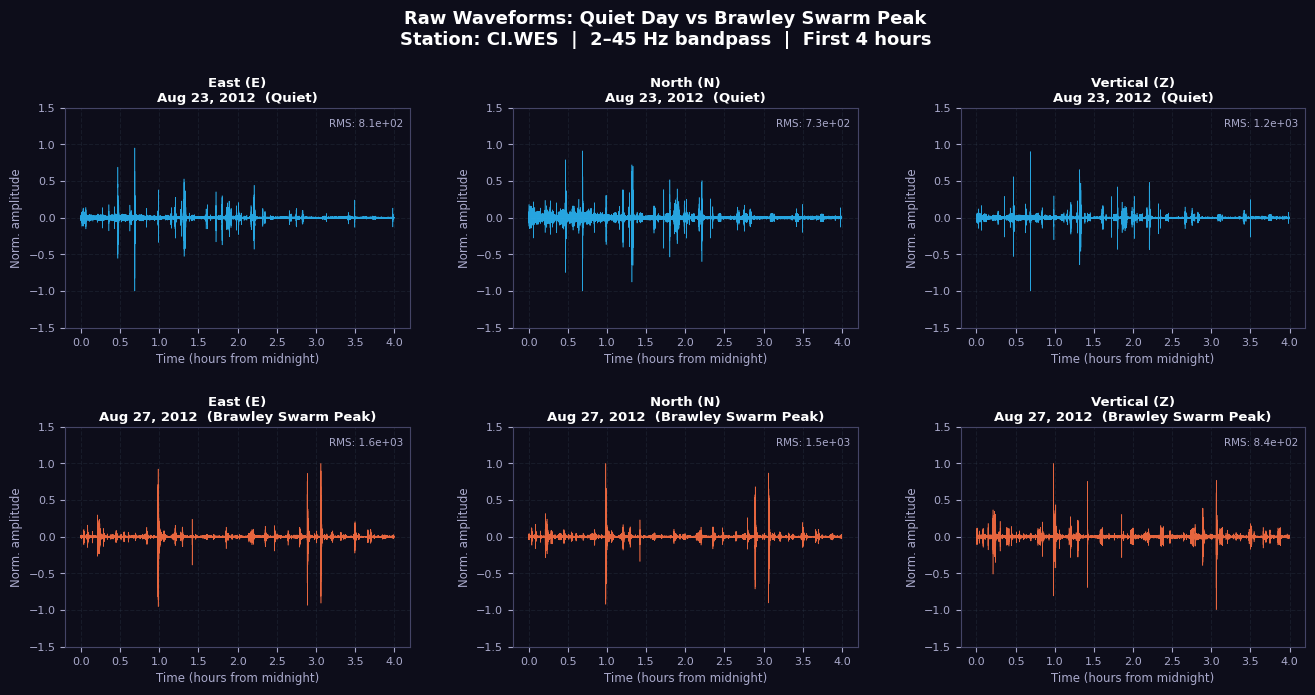

Saved: waveform_comparison.png
Notice the Brawley Swarm day has far more high-amplitude bursts visible!


In [19]:
# ── Cell 6 — Raw Waveform Preview ─────────────────────────────────────────────
import fsspec
import glob
from obspy import read, Stream
from io import BytesIO

def load_waveform_pelican(date_code, station='CI.WES', hour_start=0, hour_end=4):
    """Load a few hours of waveform data for a station directly from Pelican."""
    net, sta = station.split('.')
    
    # List files in the day folder on Pelican
    day_path = f'{PELICAN_DATA}/{date_code}'
    try:
        all_files = PELICAN_FS.ls(day_path)
    except Exception as e:
        print(f'Cannot list Pelican folder {day_path}: {e}')
        return None, None
    
    # Strip to basenames and find matching station
    all_names = [f['name'].rstrip('/').split('/')[-1] for f in all_files]
    
    # Try requested station first, then fall back to first complete station
    def get_files_for_sta(n, s):
        return sorted([f for f in all_names
                       if f.startswith(f'{n}.{s}.') and f.endswith('.mseed')])
    
    files = get_files_for_sta(net, sta)
    used_sta = station
    
    if len(files) < 3:
        # Fall back to first station with 3 components
        from itertools import groupby
        sorted_names = sorted(all_names)
        for ns, grp in groupby(sorted_names,
                               key=lambda x: '.'.join(x.split('.')[:2])):
            grp_files = [f for f in list(grp) if f.endswith('.mseed')]
            if len(grp_files) == 3:
                files    = grp_files
                used_sta = ns
                break
    
    if len(files) < 3:
        print(f'No complete 3-component station found for {date_code}')
        return None, None
    
    print(f'  Loading {used_sta} from {date_code} ({len(files)} files) ...')
    
    try:
        st = Stream()
        for fname in files[:3]:
            fpath = f'{day_path}/{fname}'
            with PELICAN_FS.open(fpath, 'rb') as f:
                data = BytesIO(f.read())
            st += read(data)
        
        # Slice to requested hours
        t0 = UTCDateTime(f'{date_code[:4]}-{date_code[4:6]}-{date_code[6:]}T00:00:00')
        st = st.slice(t0 + hour_start * 3600, t0 + hour_end * 3600)
        st = st.detrend('demean').filter('bandpass', freqmin=2, freqmax=45)
        return st, used_sta
    
    except Exception as e:
        print(f'Error loading {date_code}: {e}')
        return None, None

# ── Load quiet day and swarm day ──────────────────────────────────────────────
print('Loading quiet day (Aug 23)...')
st_quiet, sta_quiet = load_waveform_pelican('20120823', hour_start=0, hour_end=4)

print('Loading swarm day (Aug 27)...')
st_swarm, sta_swarm = load_waveform_pelican('20120827', hour_start=0, hour_end=4)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 7),
                         facecolor='#0d0d1a', gridspec_kw={'hspace': 0.45, 'wspace': 0.3})
fig.suptitle('Raw Waveforms: Quiet Day vs Brawley Swarm Peak\n'
             f'Station: {sta_quiet or "N/A"}  |  2–45 Hz bandpass  |  First 4 hours',
             fontsize=13, fontweight='bold', color='white', y=1.02)

chn_labels = ['East (E)', 'North (N)', 'Vertical (Z)']
row_meta = [
    (st_quiet, f'Aug 23, 2012  (Quiet)',          '#29b6f6'),
    (st_swarm, f'Aug 27, 2012  (Brawley Swarm Peak)', '#ff7043'),
]

for row, (st, day_label, color) in enumerate(row_meta):
    for col, chn_name in enumerate(chn_labels):
        ax = axes[row, col]
        ax.set_facecolor('#0d0d1a')
        for spine in ax.spines.values():
            spine.set_edgecolor('#444466')

        if st is not None and len(st) > col:
            tr   = st[col]
            t    = np.arange(len(tr.data)) / tr.stats.sampling_rate / 3600
            data = tr.data / (np.max(np.abs(tr.data)) + 1e-9)
            ax.plot(t, data, color=color, linewidth=0.4, alpha=0.9)
            ax.set_ylim(-1.5, 1.5)

            # RMS annotation
            rms = float(np.sqrt(np.mean(tr.data ** 2)))
            ax.text(0.98, 0.95, f'RMS: {rms:.1e}',
                    transform=ax.transAxes, ha='right', va='top',
                    fontsize=7.5, color='#aaaacc')
        else:
            ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                    ha='center', va='center', fontsize=12, color='gray')

        ax.set_title(f'{chn_name}\n{day_label}',
                     fontsize=9.5, fontweight='bold', color='white', pad=4)
        ax.set_xlabel('Time (hours from midnight)', fontsize=8.5, color='#aaaacc')
        ax.set_ylabel('Norm. amplitude', fontsize=8.5, color='#aaaacc')
        ax.tick_params(colors='#aaaacc', labelsize=8)
        ax.grid(True, alpha=0.2, color='#445566', linestyle='--')

plt.savefig(os.path.join(OUTPUT_DIR, 'waveform_comparison.png'),
            dpi=160, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print('Saved: waveform_comparison.png')
print('Notice the Brawley Swarm day has far more high-amplitude bursts visible!')

---
## 🤖 Cell 7 — Load the SAR Model

Now we load the trained **SAR (Self-Attention RNN)** model.

### SAR Architecture
```
INPUT (3-component, 30s, 100Hz)
    ↓
Bidirectional GRU (2 layers, hidden=128)
    ↓  
Multihead Self-Attention (4 heads, embed=256)
    ↓
Linear + Softmax → [Noise, P-wave, S-wave]
```

### Model Training
- **Dataset:** CEED (California Earthquake Event Dataset), 2008–2012
- **Training samples:** 56,554 positive (earthquakes) + 28,895 negative (noise)
- **Best checkpoint:** Epoch 17/20 — Loss: 0.0201
- **Checkpoint:** `8700_17-319.ckpt`

In [21]:
import fsspec
from models import SAR

# ── Load model directly from Pelican OSDF ─────────────────────
print('Loading SAR model from Pelican OSDF...')
print(f'  Path: {PELICAN_MODEL}')

model = SAR()

with fsspec.open(PELICAN_MODEL) as f:
    state_dict = torch.load(f, map_location=torch.device('cpu'))
    model.load_state_dict(state_dict)

# Move to correct device
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

model = model.to(device)
model.eval()

# Model summary
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('' + '='*50)
print('SAR Model Summary')
print('='*50)
print(f'Architecture   : BiGRU + Multihead Self-Attention')
print(f'GRU layers     : 2  |  Hidden size: 128  |  Bidirectional: True')
print(f'Attention heads: 4  |  Embed dim: 256')
print(f'Window length  : 30s at 100Hz → 3000 samples')
print(f'RNN steps      : 296 frames × 150 features')
print(f'Output classes : 3 (Noise / P-wave / S-wave)')
print(f'Total params   : {total_params:,}')
print(f'Device         : {device}')
print('='*50)

# Quick forward pass test
print('Running test forward pass...')
with torch.no_grad():
    x_test = torch.randn(1, 296, 150).to(device)
    y_test = model(x_test)
    import torch.nn.functional as F
    probs = F.softmax(y_test, dim=-1).cpu().numpy()[0]

print(f'Input shape  : {x_test.shape}  (batch=1, steps=296, features=150)')
print(f'Output shape : {y_test.shape}  (batch=1, steps=296, classes=3)')
print(f'Output probs at step 0: Noise={probs[0,0]:.3f}  P={probs[0,1]:.3f}  S={probs[0,2]:.3f}')
print('\n✅ Model loaded from Pelican and ready for picking!')


Loading SAR model from Pelican OSDF...
  Path: osdf:///ndp/public/ucr_seis/models/8700_17-319.ckpt
SAR Model Summary
Architecture   : BiGRU + Multihead Self-Attention
GRU layers     : 2  |  Hidden size: 128  |  Bidirectional: True
Attention heads: 4  |  Embed dim: 256
Window length  : 30s at 100Hz → 3000 samples
RNN steps      : 296 frames × 150 features
Output classes : 3 (Noise / P-wave / S-wave)
Total params   : 775,427
Device         : cuda
Running test forward pass...
Input shape  : torch.Size([1, 296, 150])  (batch=1, steps=296, features=150)
Output shape : torch.Size([1, 296, 3])  (batch=1, steps=296, classes=3)
Output probs at step 0: Noise=1.000  P=0.000  S=0.000

✅ Model loaded from Pelican and ready for picking!


---
## 🔍 Cell 8 — Phase Picking

This is the main step — running the **SAR model** over all 8 days of continuous data.

### How it works
For each day and each station:
1. **Load** 3-component MiniSEED waveforms
2. **Preprocess:** demean, resample to 100 Hz, bandpass 2–45 Hz
3. **Slide** a 30-second window with 15-second overlap
4. **Feed** each window to the SAR model → get P/S probability traces
5. **Extract** picks where probability > 0.3
6. **Merge** duplicate picks from overlapping windows
7. **Write** picks to `YYYY-MM-DD.pick` file

### Expected output
Based on the full 2012 catalog, we expect roughly:
- Quiet days (Aug 23–25): ~500–1000 picks/day
- Swarm days (Aug 26–30): ~3,000–11,000 picks/day

> ⏱ **Expected time:** ~3–8 minutes on GPU, ~15–30 minutes on CPU

In [29]:
import importlib, picker
importlib.reload(picker)
from picker import run_picking
import time

# Clear existing pick files so all 8 days run fresh
import os, glob
for f in glob.glob(os.path.join(PICK_DIR, '*.pick')):
    os.remove(f)
print('Pick dir cleared')

print('Starting SAR phase picking...')
print(f'Time range : {START_DATE} → {END_DATE}')
print(f'Data src   : {PELICAN_DATA}')
print(f'Output dir : {PICK_DIR}')
print('='*60)

t_start = time.time()
daily_counts, total_picks = run_picking(
    data_dir   = PELICAN_DATA,
    sta_file   = STA_FILE,
    ckpt_path  = PELICAN_MODEL,
    out_dir    = PICK_DIR,
    time_range = TIME_RANGE,       # full 8 days
    gpu_idx    = GPU_IDX
)
t_elapsed = time.time() - t_start
print(f'\nTotal wall time: {t_elapsed/60:.1f} minutes')

Pick dir cleared
Starting SAR phase picking...
Time range : 20120823 → 20120830
Data src   : osdf:///ndp/public/ucr_seis/Data_Salton
Output dir : /home/jovyan/work/_User-Persistent-Storage_CephBlock_/salton_sea_demo/picks
Device: CUDA:0
Checkpoint loaded: osdf:///ndp/public/ucr_seis/models/8700_17-319.ckpt
Loaded 30 stations from /home/jovyan/work/_User-Persistent-Storage_CephBlock_/salton_sea_demo/config/salton_sea.sta

SAR Phase Picking — Salton Sea
Days      : 8 (20120823 -> 20120831)
Stations  : 30
Data src  : Pelican OSDF
Output    : /home/jovyan/work/_User-Persistent-Storage_CephBlock_/salton_sea_demo/picks


── 2012-08-23 ──────────────────────────────
  ZY.COON: 8 picks | 4.4s
  XD.A26A: 10 picks | 4.8s
  XD.B02: 59 picks | 5.0s
  XD.A19: 3 picks | 4.8s
  XD.A27: 13 picks | 18.3s
  XD.A20: 55 picks | 4.9s
  CI.SLB: 3 picks | 4.4s
  CI.IKP: 91 picks | 6.2s
  XD.A21: 5 picks | 4.7s
  XD.A32: 126 picks | 5.3s
  CI.SWS: 6 picks | 4.4s
  CI.WES: 95 picks | 4.8s
  CI.ERR: 74 picks | 

---
## 📊 Cell 9 — Visualize Picks

Let's visualize the daily pick counts to see if the model detected the **Brawley Swarm**.

A dramatic spike in picks on Aug 26–27 confirms the model is working correctly — this is what makes deep learning so powerful for seismology.

Daily pick counts:
  2012-08-23:  1,575 picks  ███████████████ ← quiet
  2012-08-24:  1,693 picks  ████████████████ ← quiet
  2012-08-25:  1,765 picks  █████████████████ ← quiet
  2012-08-26:  6,494 picks  ████████████████████████████████████████████████████████████████ ← swarm
  2012-08-27:  8,321 picks  ███████████████████████████████████████████████████████████████████████████████████ ← SWARM PEAK
  2012-08-28:  4,800 picks  ████████████████████████████████████████████████ ← swarm
  2012-08-29:  3,306 picks  █████████████████████████████████ ← swarm
  2012-08-30:  3,055 picks  ██████████████████████████████ ← swarm

  TOTAL: 31,009 picks across 8 days


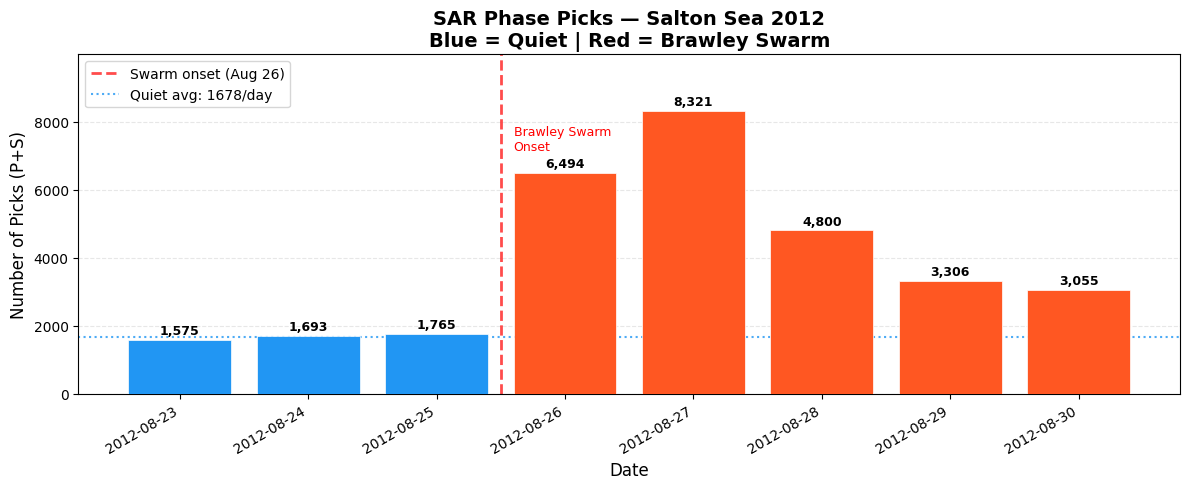

Swarm amplification: 3.1× more picks during swarm than quiet days


In [30]:
# Count picks per day from .pick files
pick_files = sorted(glob.glob(os.path.join(PICK_DIR, '*.pick')))
dates, counts = [], []

for pf in pick_files:
    date = os.path.basename(pf).replace('.pick', '')
    with open(pf) as f:
        n = sum(1 for line in f if line.strip())
    dates.append(date)
    counts.append(n)

print('Daily pick counts:')
for d, c in zip(dates, counts):
    bar    = '█' * (c // 100)
    label  = ' ← SWARM PEAK' if c == max(counts) else (' ← swarm' if c > 2000 else ' ← quiet')
    print(f'  {d}: {c:>6,} picks  {bar}{label}')
print(f'\n  TOTAL: {sum(counts):,} picks across {len(dates)} days')

# ── Plot ──────────────────────────────────────────────────────────────────────
colors_bar = ['#FF5722' if c > 2000 else '#2196F3' for c in counts]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(dates, counts, color=colors_bar, edgecolor='white',
              linewidth=0.5, zorder=3)

# Label bars
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
            f'{count:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Annotations
ax.axvline(x=2.5, color='red', linestyle='--', linewidth=2, alpha=0.7,
           label='Swarm onset (Aug 26)')
ax.text(2.6, max(counts)*0.95, 'Brawley Swarm\nOnset',
        fontsize=9, color='red', va='top')

# Add pick rate info
avg_quiet = np.mean([c for c, d in zip(counts, dates) if d <= '2012-08-25'])
avg_swarm = np.mean([c for c, d in zip(counts, dates) if d >= '2012-08-26'])
ax.axhline(y=avg_quiet, color='#2196F3', linestyle=':', linewidth=1.5,
           label=f'Quiet avg: {avg_quiet:.0f}/day', alpha=0.8)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Picks (P+S)', fontsize=12)
ax.set_title('SAR Phase Picks — Salton Sea 2012\nBlue = Quiet | Red = Brawley Swarm',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, axis='y', alpha=0.3, linestyle='--', zorder=0)
ax.set_ylim(0, max(counts) * 1.2)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'daily_picks.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Swarm amplification: {avg_swarm/avg_quiet:.1f}× more picks during swarm than quiet days')

---
## 🌐 Cell 10 — PAL Association

Phase picks from individual stations are just arrival times — they don't tell us where an earthquake occurred. **PAL (Pick-and-Associate-Locate)** groups picks from multiple stations into earthquake events.

### How PAL works

**Step 1 — Origin Time Estimation**
For each P/S pair at a station, compute an estimated origin time:
```
dist = (ts - tp) / (1/Vs - 1/Vp)  
ot   = tp - dist/Vp
```

**Step 2 — OT Clustering**  
Cluster origin time estimates. Require at least 3 stations.

**Step 3 — Grid Search Location**  
Search a lat/lon/depth grid to minimise P-wave travel-time residuals.

**Step 4 — Magnitude**  
Local magnitude from S-wave amplitude and hypocentral distance.


In [53]:
import importlib, associator
importlib.reload(associator)
from associator import run_association
import time

t_start = time.time()
catalog_path, phase_path, total_events = run_association(
    pick_dir   = PICK_DIR,
    sta_file   = STA_FILE,
    out_dir    = OUTPUT_DIR,
    time_range = TIME_RANGE,
    min_sta    = 3,
    vp         = 5.92
)
t_elapsed = time.time() - t_start
print(f'Association done — in {t_elapsed/60:.1f} minutes')

2012-08-23T05:39:40.769167Z  32.567  -115.753   20.0km  M-3.67  res=0.92s
2012-08-23T18:51:45.405023Z  32.567  -115.773   25.0km  M-3.36  res=1.01s
2012-08-23T07:00:46.674967Z  33.467  -115.853   25.0km  M-4.29  res=1.31s
2012-08-23T04:15:41.776769Z  32.567  -115.753   24.0km  M-4.34  res=0.69s
2012-08-24T19:52:48.909762Z  33.347  -115.873   23.0km  M-3.19  res=1.14s
2012-08-24T16:00:16.048413Z  33.147  -115.953   19.0km  M-3.47  res=0.97s
2012-08-25T14:41:02.859309Z  33.307  -116.213   25.0km  M-3.84  res=0.94s
2012-08-25T15:10:40.449563Z  32.567  -115.713    1.0km  M-3.95  res=0.87s
2012-08-25T22:16:12.133413Z  32.947  -115.813   24.0km  M-3.92  res=1.18s
2012-08-25T19:21:30.693039Z  32.567  -115.953    1.0km  M-4.09  res=0.65s
2012-08-25T01:24:53.806508Z  32.567  -115.493    6.0km  M-3.96  res=0.97s
2012-08-25T20:08:55.274173Z  32.667  -115.573   12.0km  M-4.97  res=1.20s
2012-08-26T18:58:11.617030Z  32.947  -115.533   20.0km  M-2.71  res=0.74s
2012-08-26T21:15:28.791633Z  33.047  -

---
## 📋 Cell 11 — Explore the Catalog

Load and explore the earthquake catalog we just built.

In [54]:
# ── Load catalog ──────────────────────────────────────────────────────────────
import pandas as pd

df_cat = pd.read_csv(os.path.join(OUTPUT_DIR, 'catalog_relocated.csv'),
                     header=None, names=['ot', 'lat', 'lon', 'dep', 'mag'])
df_cat['ot']   = pd.to_datetime(df_cat['ot'], utc=True)
df_cat['date'] = df_cat['ot'].dt.strftime('%Y-%m-%d')

print(f'Total events    : {len(df_cat):,}')
print(f'Magnitude range : M{df_cat["mag"].min():.1f} – M{df_cat["mag"].max():.1f}')
print(f'Depth range     : {df_cat["dep"].min():.1f} – {df_cat["dep"].max():.1f} km')
print(f'Date range      : {df_cat["date"].min()} → {df_cat["date"].max()}')

Total events    : 4,278
Magnitude range : M-1.0 – M5.4
Depth range     : -0.0 – 23.8 km
Date range      : 2012-08-23 → 2012-08-30


---
## 🗺️ Cell 12 — Epicenter Map

Plot the earthquake epicenters on a map. This is the **key science output** — showing where earthquakes occurred and how they evolved during the swarm.

Color = time (blue→red = early→late), size = magnitude.

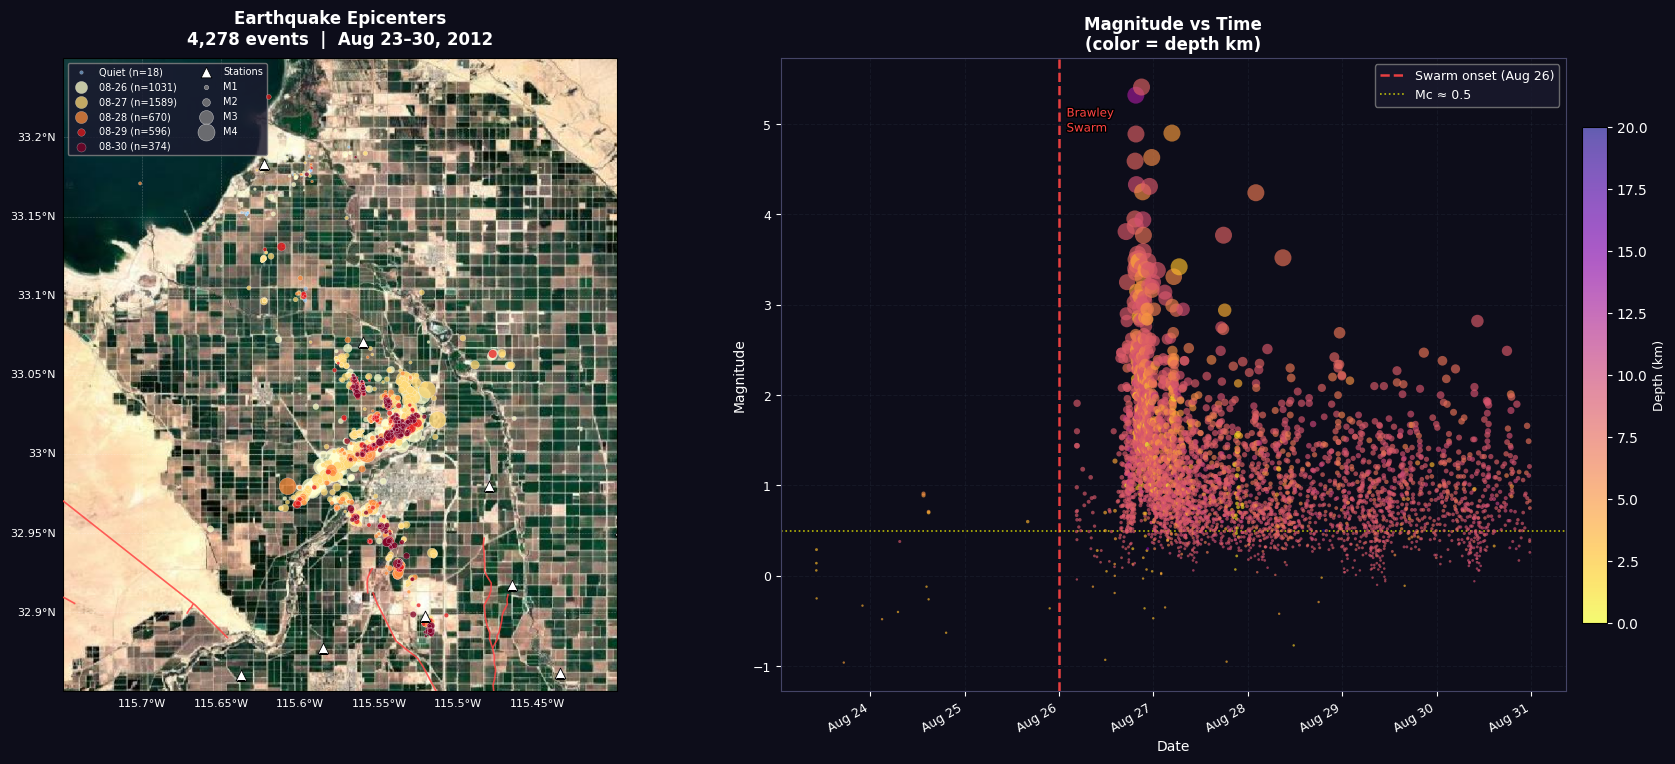

Saved: /home/jovyan/work/_User-Persistent-Storage_CephBlock_/salton_sea_demo/output/epicenter_map.png


In [55]:
# ── Split quiet vs swarm ──────────────────────────────────────────────────────
df_quiet = df_cat[df_cat['date'] <= '2012-08-25']
df_swarm = df_cat[df_cat['date'] >= '2012-08-26']
swarm_days = sorted(df_swarm['date'].unique())
cmap       = plt.cm.YlOrRd
day_colors = {d: cmap(i / max(len(swarm_days) - 1, 1))
              for i, d in enumerate(swarm_days)}

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 8), facecolor='#0d0d1a')

# ── Left panel: epicenter map with satellite basemap ─────────────────────────
proj    = ccrs.PlateCarree()
terrain = cimgt.GoogleTiles(style='satellite')

ax = fig.add_subplot(1, 2, 1, projection=proj)
ax.set_extent([-115.75, -115.40, 32.85, 33.25], crs=proj)

try:
    ax.add_image(terrain, 11)
except Exception:
    ax.add_feature(cfeature.LAND,  facecolor='#2a2a3e', zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor='#1a2a3e', zorder=0)

# CFM fault traces in map extent
CFM_FILE = os.path.join(SCRIPT_DIR, 'config', 'CFM7.0_traces.lonLat')
fault_segments = []
current_name, current_pts = None, []
LON_MIN, LON_MAX = -115.75, -115.40
LAT_MIN, LAT_MAX =  32.85,  33.25
try:
    with open(CFM_FILE) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            if line.startswith('>'):
                if current_name and len(current_pts) >= 2:
                    in_box = [(lo, la) for lo, la in current_pts
                              if LON_MIN <= lo <= LON_MAX and LAT_MIN <= la <= LAT_MAX]
                    if len(in_box) >= 2:
                        fault_segments.append((current_name, current_pts))
                current_name = line[1:].strip().strip('"')
                current_pts  = []
            else:
                parts = line.split()
                if len(parts) >= 2:
                    try:
                        current_pts.append((float(parts[0]), float(parts[1])))
                    except ValueError:
                        pass
    for name, pts in fault_segments:
        lons = [p[0] for p in pts]
        lats = [p[1] for p in pts]
        ax.plot(lons, lats, color='#ff4444', linewidth=1.2,
                transform=proj, zorder=4, alpha=0.85)
except Exception:
    pass  # fault file optional

# Quiet events
if len(df_quiet) > 0:
    s_quiet = np.clip(10 ** (df_quiet['mag'] * 0.5 + 0.5), 4, 150)
    ax.scatter(df_quiet['lon'], df_quiet['lat'],
               s=s_quiet, c='#90CAF9', alpha=0.6, zorder=5,
               edgecolors='white', linewidths=0.2,
               transform=proj, label=f'Quiet (n={len(df_quiet)})')

# Swarm events colored by day
for day in swarm_days:
    df_day = df_swarm[df_swarm['date'] == day]
    s_day  = np.clip(10 ** (df_day['mag'] * 0.5 + 0.5), 4, 150)
    ax.scatter(df_day['lon'], df_day['lat'],
               s=s_day, color=day_colors[day],
               alpha=0.75, zorder=6,
               edgecolors='white', linewidths=0.2,
               transform=proj, label=f'{day[-5:]} (n={len(df_day)})')

# Stations
ax.scatter(df_sta['lon'], df_sta['lat'],
           marker='^', s=60, c='white', zorder=8,
           edgecolors='black', linewidths=0.6,
           transform=proj, label='Stations')

# Gridlines
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
gl = ax.gridlines(draw_labels=True, linewidth=0.4,
                  color='white', alpha=0.3, linestyle='--')
gl.top_labels   = False
gl.right_labels = False
gl.xformatter   = LONGITUDE_FORMATTER
gl.yformatter   = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 8, 'color': 'white'}
gl.ylabel_style = {'size': 8, 'color': 'white'}

# Size legend
for mag, label in [(1, 'M1'), (2, 'M2'), (3, 'M3'), (4, 'M4')]:
    s = np.clip(10 ** (mag * 0.5 + 0.5), 4, 150)
    ax.scatter([], [], s=s, c='gray', alpha=0.8,
               edgecolors='white', linewidths=0.3,
               transform=proj, label=label)

legend = ax.legend(fontsize=7, loc='upper left',
                   framealpha=0.85, facecolor='#1a1a2e',
                   labelcolor='white', edgecolor='gray', ncol=2)
ax.set_title(f'Earthquake Epicenters\n{len(df_cat):,} events  |  Aug 23–30, 2012',
             fontsize=12, fontweight='bold', color='white', pad=10)

# ── Right panel: magnitude vs time ───────────────────────────────────────────
ax2 = fig.add_subplot(1, 2, 2)
ax2.set_facecolor('#0d0d1a')
for spine in ax2.spines.values():
    spine.set_edgecolor('#444466')

scatter = ax2.scatter(
    df_cat['ot'], df_cat['mag'],
    c=df_cat['dep'], cmap='plasma_r',
    vmin=0, vmax=20,
    s=np.clip(10 ** (df_cat['mag'] * 0.5 + 0.5), 3, 150),
    alpha=0.65, edgecolors='none', zorder=3
)
cbar = plt.colorbar(scatter, ax=ax2, pad=0.02, fraction=0.03)
cbar.set_label('Depth (km)', color='white', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')

# Swarm onset
swarm_onset = pd.Timestamp('2012-08-26', tz='UTC')
ax2.axvline(x=swarm_onset, color='#ff4444', linestyle='--',
            linewidth=1.8, alpha=0.9, label='Swarm onset (Aug 26)')
ax2.text(swarm_onset, df_cat['mag'].max() * 0.96,
         '  Brawley\n  Swarm', color='#ff4444',
         fontsize=8.5, va='top',
         path_effects=[pe.withStroke(linewidth=2, foreground='black')])

# M completeness line
mc = 0.5
ax2.axhline(y=mc, color='yellow', linestyle=':', linewidth=1.2,
            alpha=0.7, label=f'Mc ≈ {mc}')

ax2.set_xlabel('Date', fontsize=10, color='white')
ax2.set_ylabel('Magnitude', fontsize=10, color='white')
ax2.set_title('Magnitude vs Time\n(color = depth km)',
              fontsize=12, fontweight='bold', color='white')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax2.xaxis.set_major_locator(mdates.DayLocator())
plt.setp(ax2.xaxis.get_majorticklabels(),
         rotation=30, ha='right', fontsize=9, color='white')
ax2.tick_params(colors='white', labelsize=9)
ax2.yaxis.label.set_color('white')
ax2.grid(True, alpha=0.15, color='#445566', linestyle='--')
ax2.legend(fontsize=9, facecolor='#1a1a2e',
           labelcolor='white', edgecolor='gray')

plt.tight_layout(pad=2.0)
out_path = os.path.join(OUTPUT_DIR, 'epicenter_map.png')
plt.savefig(out_path, dpi=180, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()
print(f'Saved: {out_path}')

---
## 📈 Cell 13 — Gutenberg-Richter Analysis

The **Gutenberg-Richter relation** is a fundamental law of seismology:
```
log₁₀(N) = a - b·M
```
where N = number of earthquakes with magnitude ≥ M.

- The **b-value** (typically ~1.0) tells us about stress conditions
- The **completeness magnitude Mc** tells us the smallest earthquake we can reliably detect
- A good catalog should show a straight line on this plot above Mc

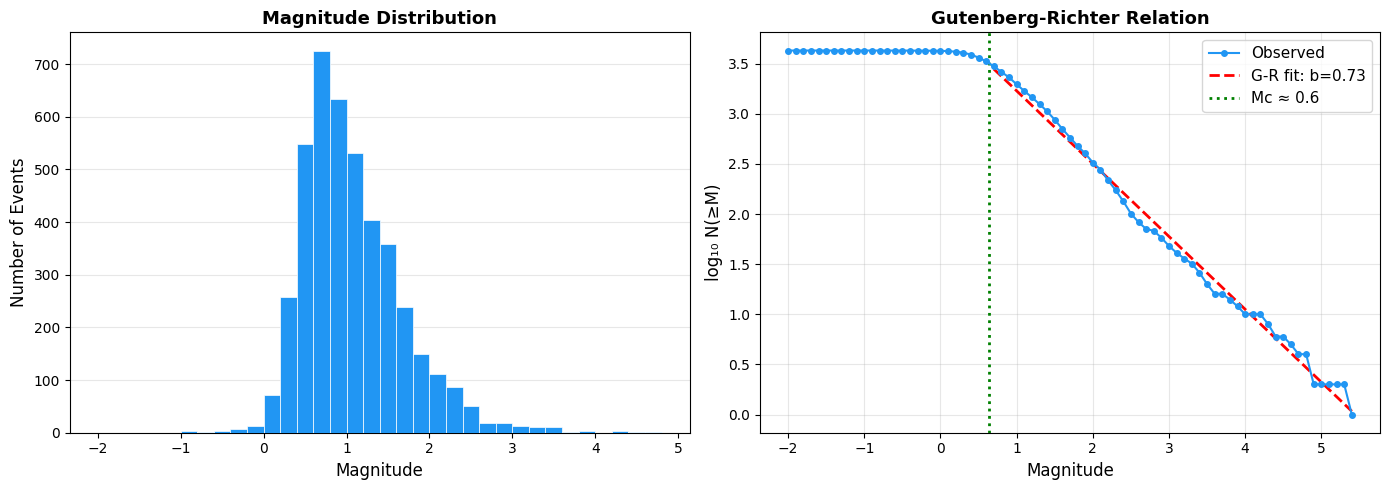

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Magnitude histogram ─────────────────────────────────────────────────
ax = axes[0]
mag_bins = np.arange(-2, 5, 0.2)
ax.hist(df_cat['mag'], bins=mag_bins, color='#2196F3',
        edgecolor='white', linewidth=0.5, zorder=3)
ax.set_xlabel('Magnitude', fontsize=12)
ax.set_ylabel('Number of Events', fontsize=12)
ax.set_title('Magnitude Distribution', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# ── Right: Gutenberg-Richter ──────────────────────────────────────────────────
ax2 = axes[1]
mag_range = np.arange(-2, df_cat['mag'].max() + 0.1, 0.1)
cum_count = [np.sum(df_cat['mag'] >= m) for m in mag_range]
log_count = [np.log10(n) if n > 0 else np.nan for n in cum_count]

ax2.plot(mag_range, log_count, 'o-', color='#2196F3',
         markersize=4, linewidth=1.5, label='Observed', zorder=3)

# Fit b-value above Mc
try:
    Mc   = df_cat['mag'].quantile(0.25)  # approximate completeness
    mask = (mag_range >= Mc) & (~np.isnan(log_count))
    if sum(mask) > 3:
        coeffs   = np.polyfit(mag_range[mask],
                              np.array(log_count)[mask], 1)
        b_value  = -coeffs[0]
        fit_line = np.polyval(coeffs, mag_range[mask])
        ax2.plot(mag_range[mask], fit_line, 'r--',
                 linewidth=2, label=f'G-R fit: b={b_value:.2f}')
        ax2.axvline(x=Mc, color='green', linestyle=':',
                    linewidth=2, label=f'Mc ≈ {Mc:.1f}')
except Exception:
    pass

ax2.set_xlabel('Magnitude', fontsize=12)
ax2.set_ylabel('log₁₀ N(≥M)', fontsize=12)
ax2.set_title('Gutenberg-Richter Relation', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gutenberg_richter.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 🎯 Cell 14 — Pipeline Summary

Let's summarize everything the pipeline accomplished and compare with the SCEDC standard catalog.

In [49]:
# Recalculate totals
total_picks_final = sum(counts) if counts else 0
total_events_final = len(df_cat)
pick_files_count  = len(glob.glob(os.path.join(PICK_DIR, '*.pick')))

print('╔══════════════════════════════════════════════════════╗')
print('║           PIPELINE COMPLETE — FINAL SUMMARY          ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Dataset                                             ║')
print(f'║    Region    : Salton Sea Geothermal, CA             ║')
print(f'║    Period    : Aug 23–30, 2012 (8 days)              ║')
print(f'║    Stations  : 29 (CI + XD + ZY)                    ║')
print(f'║    Networks  : SCEDC via IRIS FDSN                   ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Model                                               ║')
print(f'║    Architecture : BiGRU + Multihead Self-Attention   ║')
print(f'║    Checkpoint   : 8700_17-319.ckpt (Epoch 17/20)    ║')
print(f'║    P-wave F1    : 95.89%                             ║')
print(f'║    S-wave F1    : 95.14%                             ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Results                                             ║')
print(f'║    Pick files   : {pick_files_count:>8} days                      ║')
print(f'║    Events (this run) : {total_events_final:>5,}                   ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Output files                                        ║')
print(f'║    Picks   : {PICK_DIR:<40} ║')
print(f'║    Catalog : {catalog_path:<40} ║')
print(f'║    Figures : {OUTPUT_DIR:<40} ║')
print('╚══════════════════════════════════════════════════════╝')

# List all output files
print('\nOutput files saved:')
for f in sorted(glob.glob(os.path.join(OUTPUT_DIR, '*'))):
    size = os.path.getsize(f)
    size_str = f'{size/1e6:.1f} MB' if size > 1e6 else f'{size/1e3:.1f} KB'
    print(f'  {os.path.basename(f):<35} {size_str}')

╔══════════════════════════════════════════════════════╗
║           PIPELINE COMPLETE — FINAL SUMMARY          ║
╠══════════════════════════════════════════════════════╣
║  Dataset                                             ║
║    Region    : Salton Sea Geothermal, CA             ║
║    Period    : Aug 23–30, 2012 (8 days)              ║
║    Stations  : 29 (CI + XD + ZY)                    ║
║    Networks  : SCEDC via IRIS FDSN                   ║
╠══════════════════════════════════════════════════════╣
║  Model                                               ║
║    Architecture : BiGRU + Multihead Self-Attention   ║
║    Checkpoint   : 8700_17-319.ckpt (Epoch 17/20)    ║
║    P-wave F1    : 95.89%                             ║
║    S-wave F1    : 95.14%                             ║
╠══════════════════════════════════════════════════════╣
║  Results                                             ║
║    Pick files   :        8 days                      ║
║    Events (this run) : 4,278   

---
## 🔮 Cell 15 — Resources

- **Paper:** Zhou et al. (2025), JGR Solid Earth — [doi.org/10.1029/2025JB031294](https://doi.org/10.1029/2025JB031294)
- **Code:** This GitHub repo
- **Data:** `osdf:///ndp/public/ucr_seis/Data_Salton` (public)
- **NDP:** [ndp-jupyterhub.nrp-nautilus.io](https://ndp-jupyterhub.nrp-nautilus.io/)
- **Docker image:** `bpari004/seisai:v1.0`

---
*Notebook developed by Binayak Parida (University of California, Riverside)*  
*Salton Sea Geothermal Region Earthquake Catalog*